# Thematic Screener: Assess Entities Exposed to Trends

## Why It Matters

Thematic investing requires systematic identification of entities aligned with structural trends, but manually tracking exposure across thousands of documents is inefficient and inconsistent. As mega-trends like AI reshape markets, investors need scalable ways to quantify which entities are genuinely positioned to benefit.

## What It Does

The `ThematicScreener` class in the bigdata-research-tools package helps solve this problem. Designed for analysts, PMs, and strategists managing thematic portfolios or scouting new ideas, it systematically connects entities such as Currencies, Commodities, Cryptocurrencies to investment themes using unstructured data from news, earnings calls, and filings.

## How It Works

ThematicScreener combines **LLM-powered theme taxonomies**, **semantic content retrieval**, and **structured scoring methodologies** to deliver:

- **Automated theme breakdown** into specific, measurable sub-categories
- **Systematic positioning analysis** to identify how entities align with key themes
- **Cross-sector exposure comparison** enabling portfolio-level thematic assessment
- **Qualitative-to-quantitative transformation** that turns narrative signals into structured, actionable insights

## A Real-World Use Case

This cookbook walks through a full workflow, from defining a theme to quantifying cryptocurrency exposure, using "Cryptocurrency Institutional Adoption" analysis across 20 cryptocurrencies as a practical example.


## Async Compatibility Setup

**Run this cell first** - Required for Google Colab, Jupyter Notebooks, and VS Code with Jupyter extension:

### Why is this needed?

Interactive environments (Colab, Jupyter) already have an asyncio event loop running. When bigdata-research-tools makes async API calls (like to OpenAI), you'll get this error without nest_asyncio:

```
RuntimeError: asyncio.run() cannot be called from a running event loop
```

The `nest_asyncio.apply()` command patches this to allow nested event loops.

💡 **Tip**: If you're unsure which environment you're in, just run the cell below - it won't hurt in any environment!

In [1]:
import datetime
start = datetime.datetime.now()

try:
    import asyncio
    asyncio.get_running_loop()
    import nest_asyncio; nest_asyncio.apply()
    print("✅ nest_asyncio applied")
except (RuntimeError, ImportError):
    print("✅ nest_asyncio not needed or not available")

✅ nest_asyncio applied


## Environment Setup

The following cell configures the necessary path for the analysis

In [2]:
import os
import sys

current_dir = os.getcwd()
if current_dir not in sys.path:
    sys.path.append(current_dir)
print(f"✅ Local environment setup complete")

✅ Local environment setup complete


## Import Required Libraries

In [3]:
from bigdata_client import Bigdata
from bigdata_client.models.search import DocumentType
from bigdata_research_tools.themes import (
    generate_theme_tree,
)
from bigdata_research_tools.labeler.screener_labeler import ScreenerLabeler
from bigdata_research_tools.workflows.utils import get_scored_df
from src.search_entities import search_by_entities, post_process_dataframe
import pandas as pd

## Optional: Plotly Display Configuration

For better visualization rendering, you can also set the Plotly renderer:

In [4]:
import plotly.io as pio

# Try to detect the environment and set appropriate renderer
try:
    # Check if we're in JupyterLab
    import os
    if 'JUPYTERHUB_SERVICE_PREFIX' in os.environ or 'JPY_SESSION_NAME' in os.environ:
        pio.renderers.default = 'jupyterlab'
        print("✅ Plotly configured for JupyterLab")
    else:
        # Default for VS Code, Jupyter Notebook, etc.
        pio.renderers.default = 'plotly_mimetype+notebook'
        print("✅ Plotly configured for Jupyter/VS Code")
except:
    # Fallback to a more universal renderer
    pio.renderers.default = 'notebook'
    print("✅ Plotly configured with fallback renderer")

✅ Plotly configured for Jupyter/VS Code


## Define Output Paths

We define the output paths for our thematic screening results.

In [5]:
# Define output file paths for our results
output_dir = "output"
os.makedirs(output_dir, exist_ok=True)

export_path = f"{output_dir}/thematic_screener_results.xlsx"

## Load Credentials

In [6]:
from dotenv import load_dotenv
from pathlib import Path

script_dir = Path(__file__).parent if '__file__' in globals() else Path.cwd()
#load_dotenv(script_dir / '.env')
load_dotenv('/home/abouchs/.python_env_var/.env')

BIGDATA_USERNAME = os.getenv('BIGDATA_USERNAME')
BIGDATA_PASSWORD = os.getenv('BIGDATA_PASSWORD')
OPENAI_API_KEY = os.getenv('OPENAI_API_KEY')

if not all([BIGDATA_USERNAME, BIGDATA_PASSWORD, OPENAI_API_KEY]):
    print("❌ Missing required environment variables")
    raise ValueError("Missing required environment variables. Check your .env file.")
else:
    print("✅ Credentials loaded from .env file")

✅ Credentials loaded from .env file


## Connecting to Bigdata

Create a Bigdata object with your credentials.

In [7]:
bigdata = Bigdata(BIGDATA_USERNAME, BIGDATA_PASSWORD)

## Defining your Screening Parameters

-  **Main Theme** (``main_theme``): The central concept to explore
-  **Entity Universe** (``entities``): The set of entities to screen
-  **Control Entities** (``control_entities``): The set of entities to be always comentioned with your watchlist (e.g. people, places, organizations, etc)
-  **Time Period** (``start_date`` and ``end_date``): The date range over which to
   run the search
-  **Document Type** (``document_type``): Specify which documents to search over
   (transcripts, filings, news)
-  **Sources** (``sources``): Specify set of sources within a document type, for
   example which news outlets (available via Bigdata API) you wish to
   search over
-  **Fiscal Year** (``fiscal_year``): If the document type is transcripts or
   filings, fiscal year needs to be specified
-  **Model Selection** (``llm_model``): The LLM model used to mindmap the theme
   and label the search result chunks
-  **Rerank Threshold** (``rerank_threshold``): By setting this value, you’re
   enabling the cross-encoder which reranks the results and selects
   those whose relevance is above the percentile you specify (0.7 being
   the 70th percentile). More information on the re-ranker can be found
   [here](https://sdk.bigdata.com/en/latest/how_to_guides/rerank_search.html).
-  **Focus** (``focus``): Specify a focus within the main theme. This will then
   be used in building the LLM generated mindmapper

In [8]:
# ===== Theme Definition =====
main_theme = "Energy Transition and Diversification"
focus="Generate a mind map of current and future trends in Energy that will directly impact resource exploration, investments, and overall future outlooks in energy commodities, rare earths, and semiconductors"

# ===== Entity Universe (from Watchlist) =====
# Get Energy, Rare Earths & Semiconductors watchlist from Bigdata.com
top100_watchlist_id = "5ec91ce2-fbf6-4900-ae1f-1f4c0076a368"
watchlist = bigdata.watchlists.get(top100_watchlist_id)
entities = bigdata.knowledge_graph.get_entities(watchlist.items)
control_entities = None

# ===== LLM Specification =====
llm_model = "openai::gpt-4o-mini"

# ===== Docs Configuration =====
document_type = DocumentType.NEWS
fiscal_year = None

# ===== Enable/Disable Reranker =====
rerank_threshold = None

# ===== Specify Time Range =====
start_date = "2025-01-01"
end_date = "2025-09-11"

## Mindmap a Theme Taxonomy with Bigdata Research Tools

You can leverage Bigdata Research Tools to generate a comprehensive theme taxonomy with an LLM, breaking down a megatrend into smaller,
well-defined concepts for more targeted analysis.

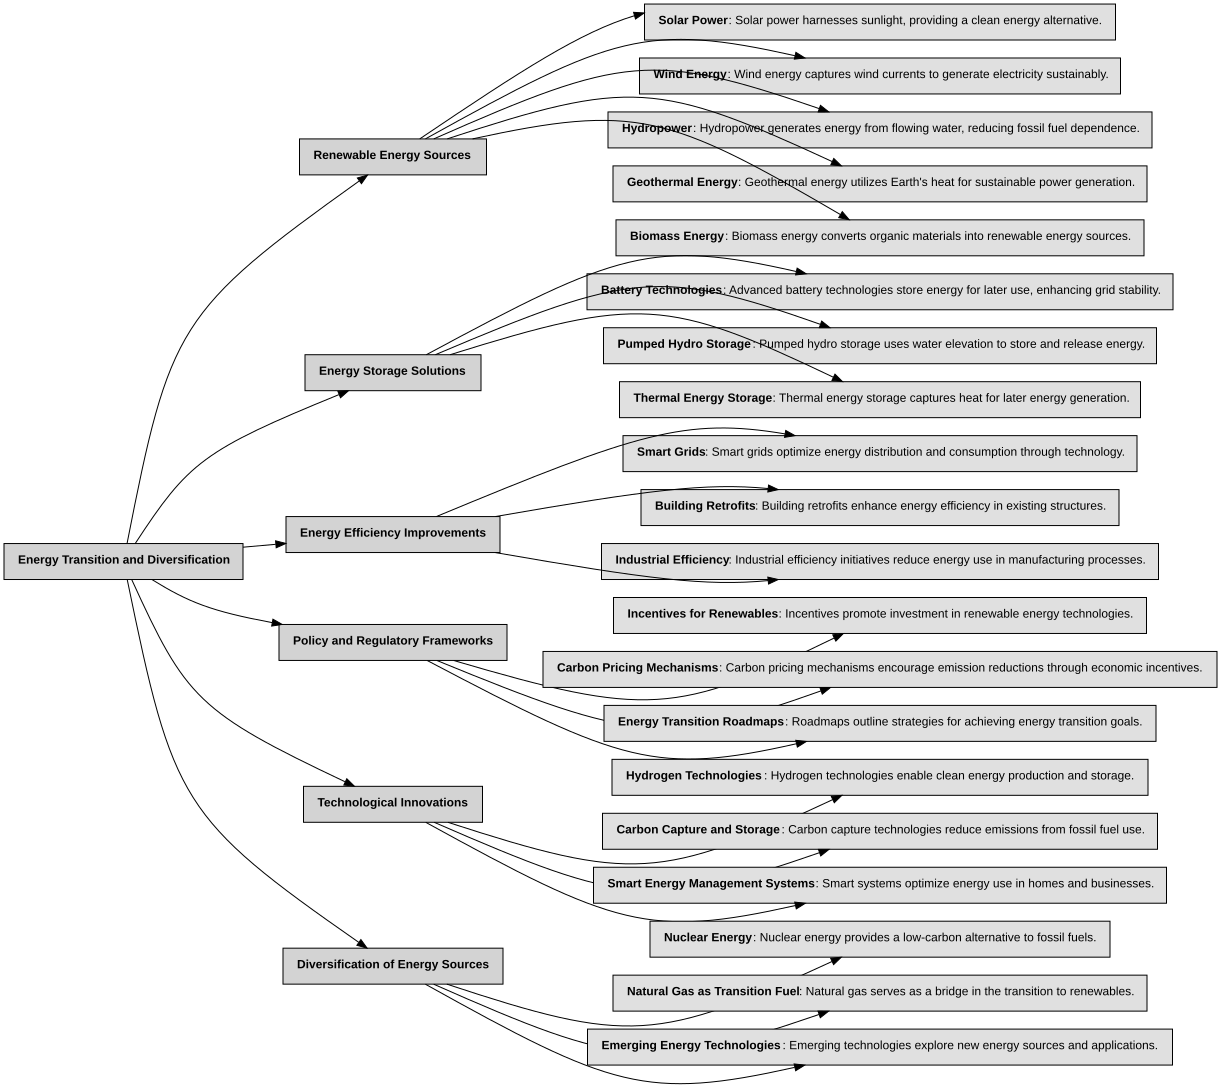

In [9]:
theme_tree = generate_theme_tree(
    main_theme=main_theme,
    focus=focus,
)

theme_tree.visualize()

The taxonomy tree includes descriptive sentences that explicitly connect each sub-theme back to the main theme, ensuring all search results remain contextually relevant to our central trend.

In [10]:
node_summaries = theme_tree.get_summaries()
labels=list(theme_tree.get_terminal_label_summaries().keys())

## Retrieve Content using Bigdata’s Search Capabilities

With the theme taxonomy and screening parameters, you can leverage the
Bigdata API to run a search on news or company transcripts. We need to define 3
more parameters for searching:

-  **Frequency** (``freq``): The frequency of the date ranges to search over.
   Supported values:

   -  `Y`: Yearly intervals.
   -  `M`: Monthly intervals.
   -  `W`: Weekly intervals.
   -  `D`: Daily intervals. Defaults to `3M`.

-  **Document Limit** (``document_limit``): The maximum number of documents to
   return per query to Bigdata API.
-  **Batch Size** (``batch_size``): The number of entities to include in a
   single batched query.

In [11]:
freq = "3M"
document_limit = 10
batch_size = 10

In [12]:
df_sentences = search_by_entities(entities=entities,
    sentences=node_summaries,
    start_date=start_date,
    end_date=end_date,
    scope=document_type,
    sources=None,
    fiscal_year=None,
    freq=freq,
    document_limit=document_limit,
    batch_size=batch_size
)

Running 324 searches (108 queries over 3 date ranges)
Example query:
And(Similarity('Building retrofits enhance energy efficiency in existing structures.'), Or(Entity('9539B6'), Concept(id='C1FF62', name='Indium', volume=None, description='Indium is a soft, malleable metal with a brilliant luster and excellent electrical conductivity. It is primarily used in touchscreens, solar panels, and aircraft engine coatings.', entity_type='CMDT', entity_type_name='Commodity', concept_level_2=None, concept_level_3=None, concept_level_4=None, concept_level_5=None), Concept(id='C49E6D', name='Nuclear', volume=None, description="Nuclear refers to the energy from a changing atom's structure. It is mainly used for generating energy.  ", entity_type='CMDT', entity_type_name='Commodity', concept_level_2=None, concept_level_3=None, concept_level_4=None, concept_level_5=None), Concept(id='7FE5D5', name='Renewable Fuel', volume=None, description='Renewable Fuels are fuels produced from renewable resources.

Processing news results...: 100%|██████████| 3240/3240 [00:00<00:00, 4538.07it/s]


## Label the Results

Use an LLM to analyze each text chunk and determine its relevance to the sub-themes. Any chunks which aren't explicitly linked to our main theme will be filtered out.

In [13]:
labeler = ScreenerLabeler(llm_model=llm_model)
df_labels = labeler.get_labels(
    main_theme=main_theme,
    labels=list(theme_tree.get_terminal_label_summaries().keys()),
    texts=df_sentences["masked_text"].tolist(),
)

Querying an LLM...: 100%|██████████| 5344/5344 [05:55<00:00, 15.03it/s]


In [14]:
# Merge and process results
df = pd.merge(df_sentences, df_labels, left_index=True, right_index=True)

In [15]:
df = post_process_dataframe(df)

## Assess Thematic Exposure Across Your Entities

We’ll look at the top 10 most exposed companies to our main theme. The function `get_scored_df` will calculate the composite
thematic score, summing up the scores across the sub-themes for each
entity (`df_entity`).

In [16]:
df_entity = pd.DataFrame()

df_entity = get_scored_df(
    df, index_columns=["Entity"], pivot_column="Theme"
)

In [17]:
from src.visualization_tool import display_figures

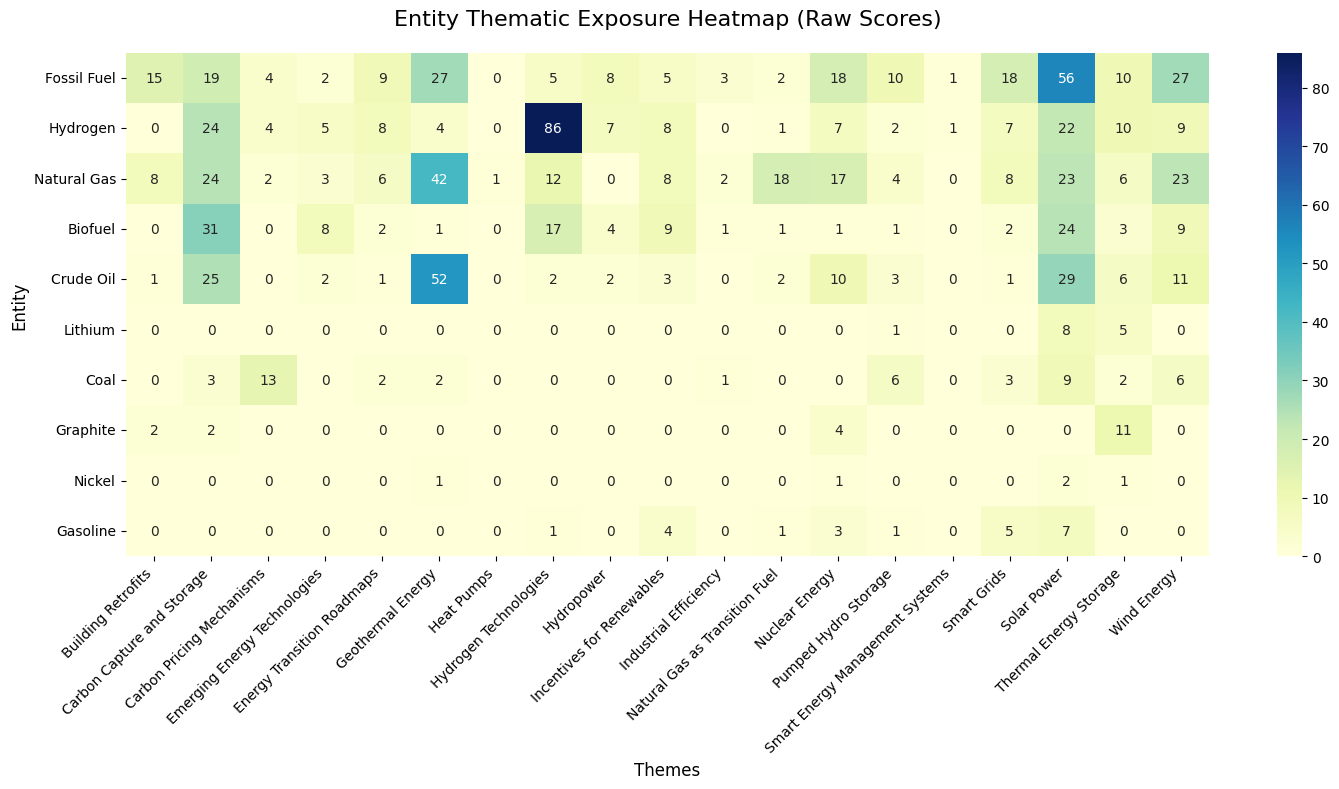

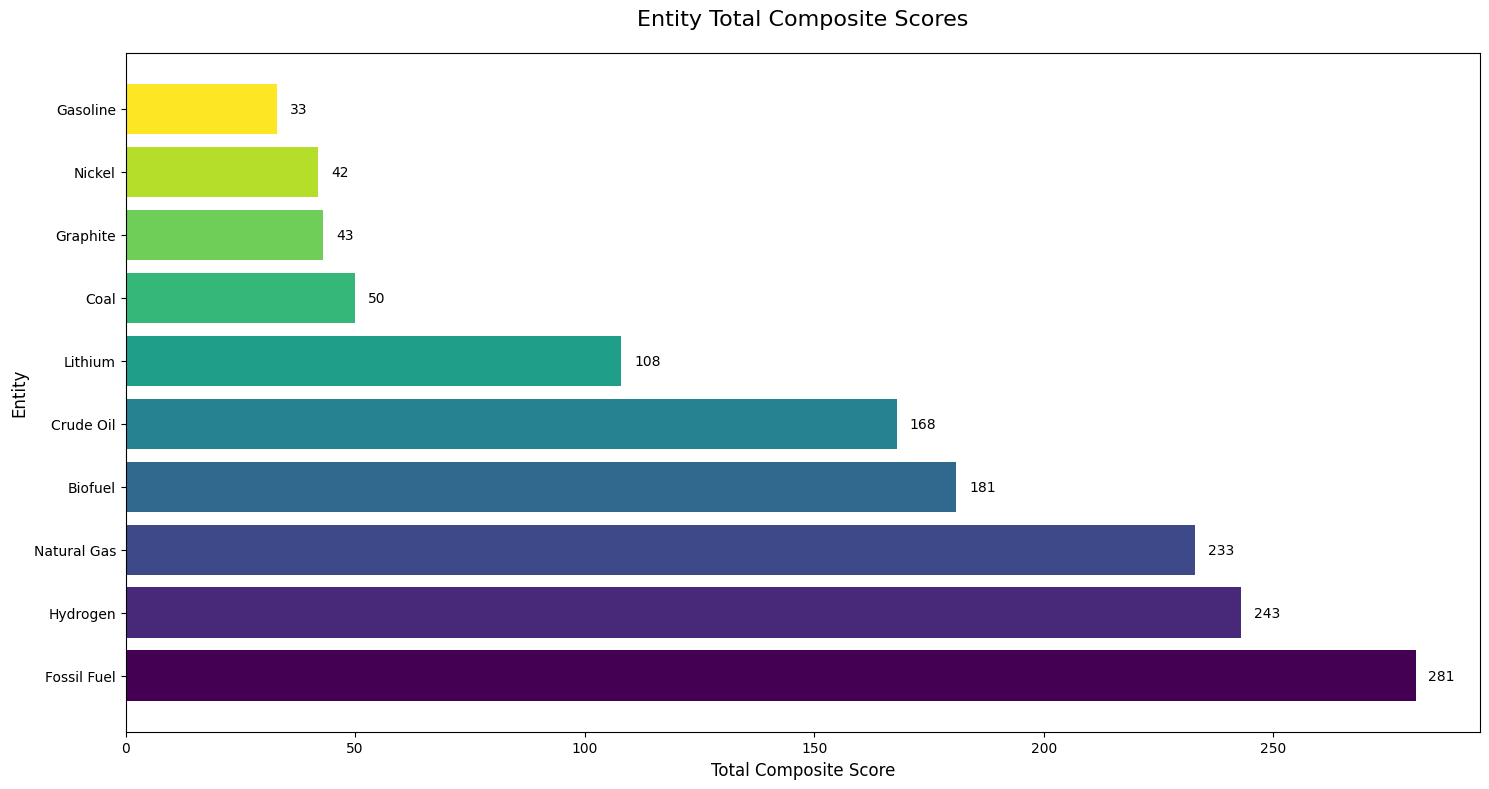

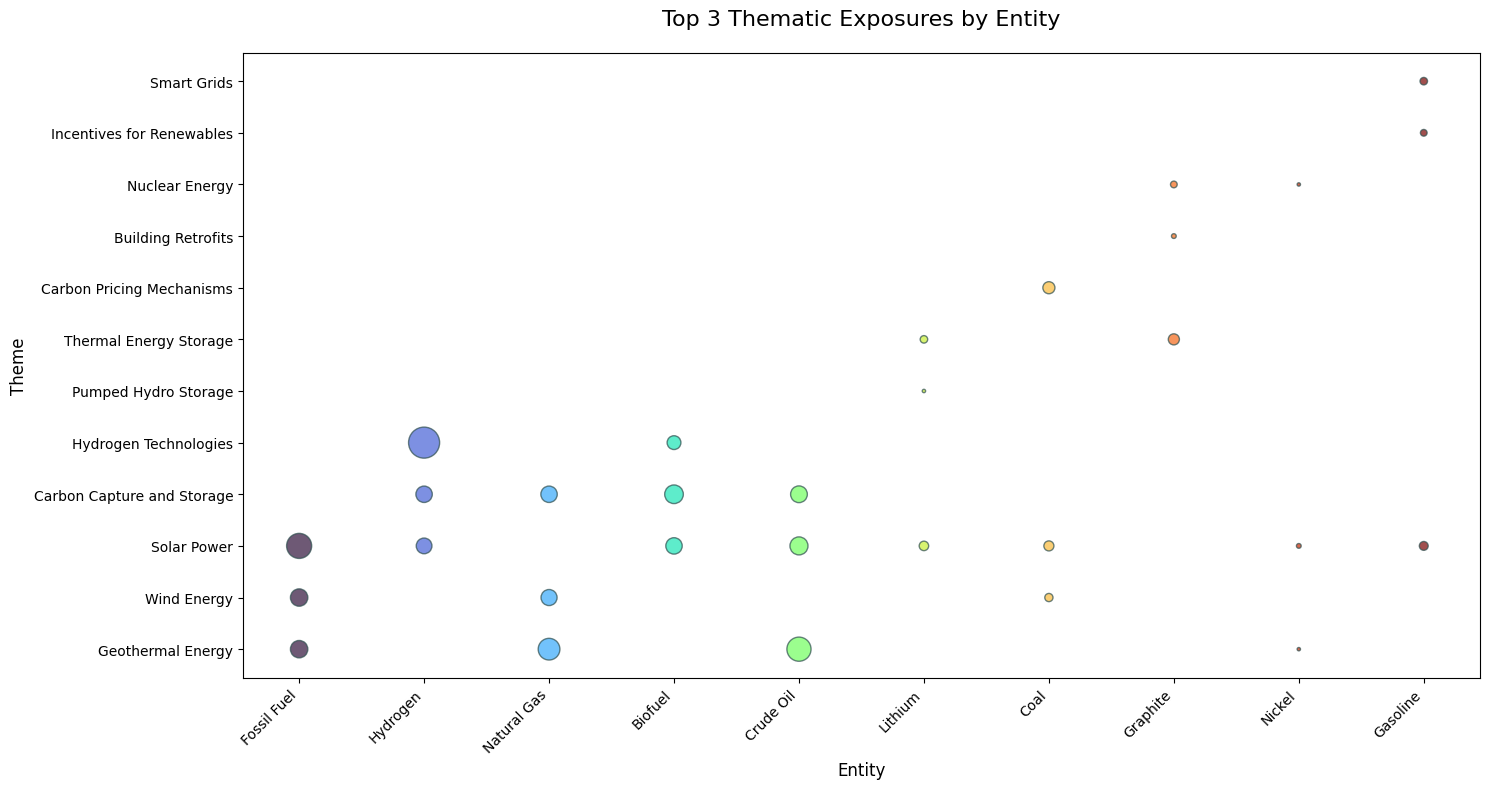

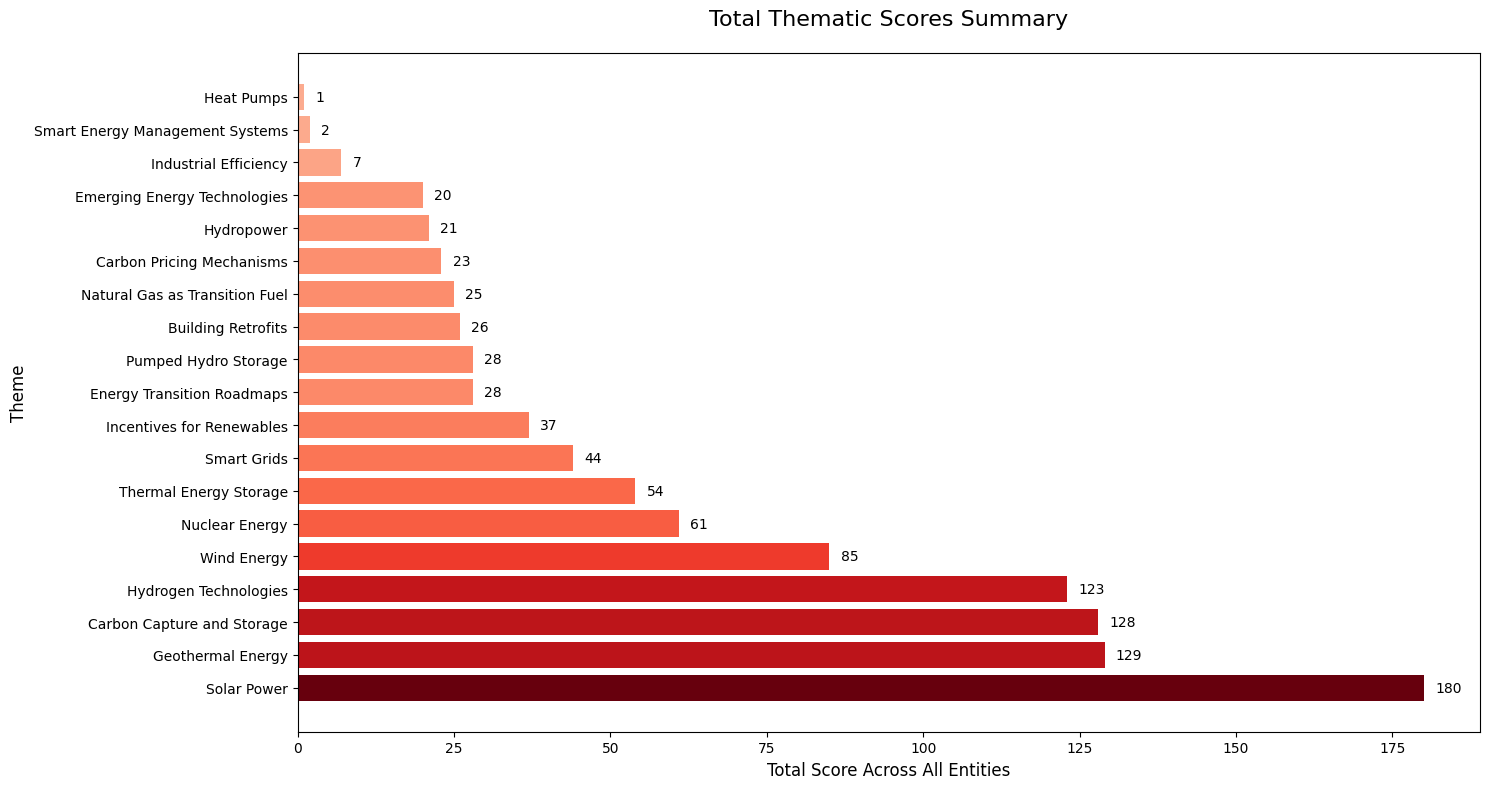

In [18]:
display_figures(df_entity, interactive=False, n_entities=10)